In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os 

In [2]:
combined_df = pd.read_csv('combined_fish_data.csv')
df_yearly = pd.read_csv('yearly_fish_data.csv')

## Grindavík: From Stable Fishing Hub to Volcanic Uncertainty

For decades, Grindavík was one of Iceland’s most consistent fishing ports and saw a consistent rise until a great decline in capelin catches began in 2004. While several major harbors experienced large fluctuations in landings over time, Grindavík maintained relatively stable catch volumes after the capelin decline. This stability reflected the town’s strong fishing infrastructure and its importance within Iceland’s fisheries sector.

After 2021, however, the data shows a sharp and sustained decline in landings at Grindavík. Unlike earlier downturns that were primarily linked to changing fish stocks or quota allocations, this decline coincides with the volcanic activity on the Reykjanes Peninsula. Beginning in 2021 and intensifying in later years, repeated eruptions and seismic activity disrupted daily life, infrastructure, and economic activity in the region. The fisheries data suggests that these natural events may have significantly affected the operation of Grindavík as a landing harbor, marking a dramatic shift in the town’s long-standing role in Icelandic fisheries.

In [3]:
# --- Theme colors  ---
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#30363d"
TEXT = "#c9d1d9"
MUTED = "#8b949e"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": TEXT,
    "axes.titlecolor": "#f0f6fc",
    "grid.color": GRID,
    "legend.facecolor": PANEL,
    "legend.edgecolor": GRID,
    "font.family": "DejaVu Sans"
})

# --- Original-style distinct matplotlib colors ---
SPECIES_COLORS = {
    "Capelin": "#1f77b4",        # blue
    "Cod": "#ff7f0e",   # orange
    "Haddock": "#2ca02c",   # green
    "Herring": "#d62728",   # red
    "Mackerel": "#9467bd",  # purple
}


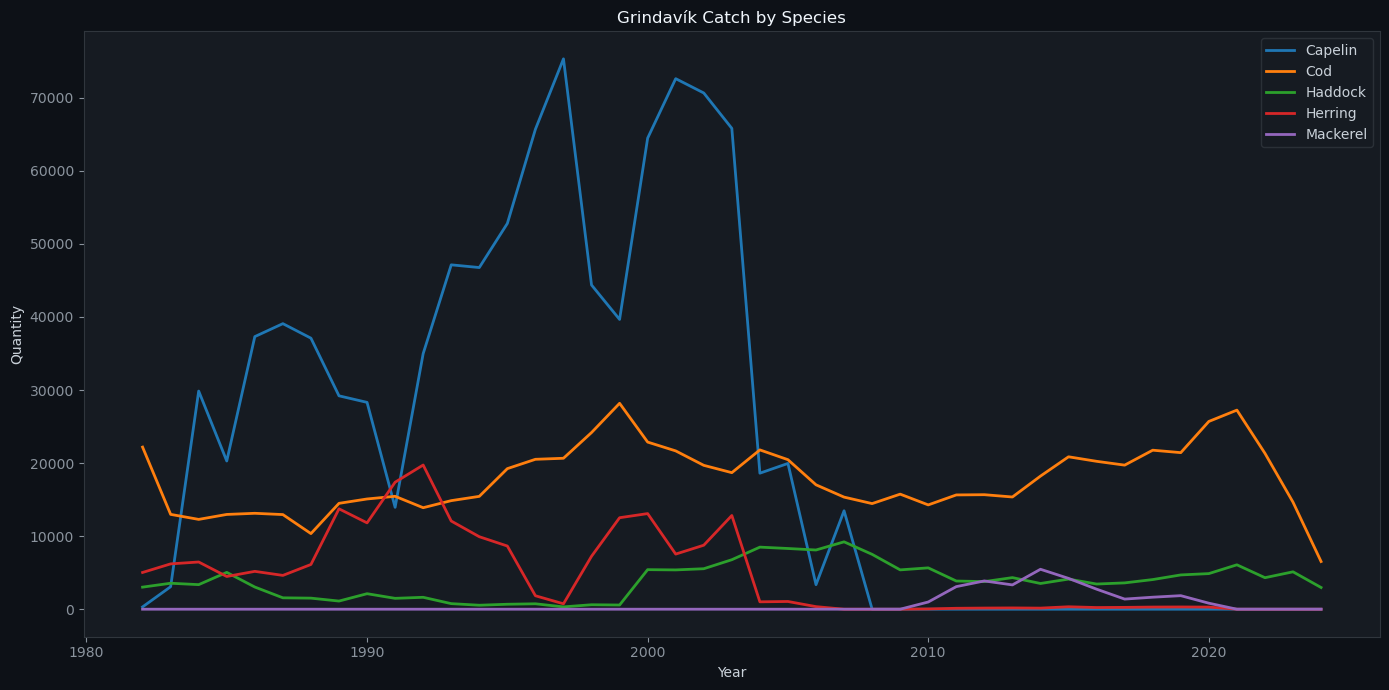

In [4]:
grindavik = df_yearly[df_yearly["Port"] == "Grindavík"]

species_port = (
    grindavik
    .groupby(["Year", "Species"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14,7))

for col in species_port.columns:
    plt.plot(
        species_port.index,
        species_port[col],
        linewidth=2,
        label=col
    )

#plt.axvline(2004, linestyle="--")
plt.title("Grindavík Catch by Species")
plt.xlabel("Year")
plt.ylabel("Quantity")
plt.legend()

plt.tight_layout()
plt.show()

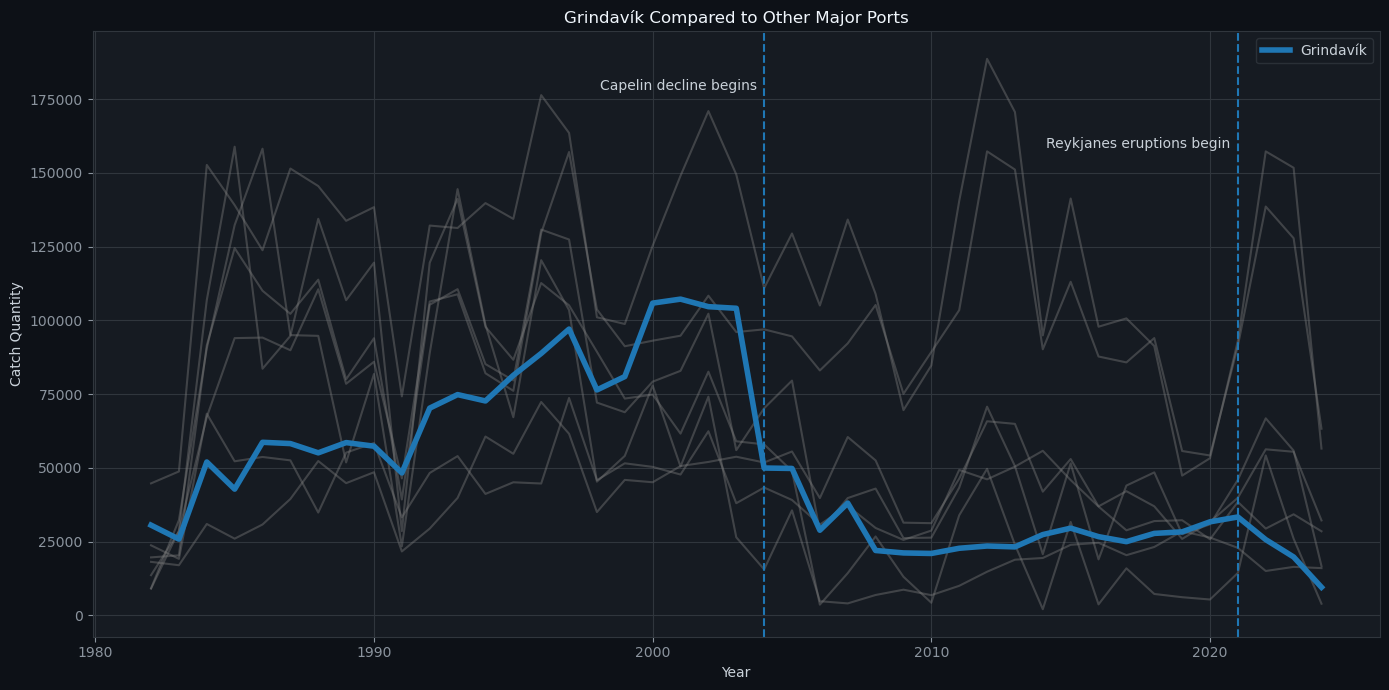

In [5]:
top_ports = (
    df_yearly
    .groupby("Port")["Quantity"]
    .sum()
    .nlargest(8)
    .index
)

top_df = df_yearly[df_yearly["Port"].isin(top_ports)]

pivot_ports = (
    top_df
    .groupby(["Year", "Port"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))

for port in pivot_ports.columns:
    if port != "Grindavík":
        plt.plot(
            pivot_ports.index,
            pivot_ports[port],
            color="gray",
            alpha=0.4,
            linewidth=1.5
        )

plt.plot(
    pivot_ports.index,
    pivot_ports["Grindavík"],
    linewidth=4,
    label="Grindavík"
)

plt.axvline(2004, linestyle="--")
plt.axvline(2021, linestyle="--")

plt.text(2004 - 5.9, plt.ylim()[1]*0.9, "Capelin decline begins")
plt.text(2021 -6.9, plt.ylim()[1]*0.8, "Reykjanes eruptions begin")

plt.title("Grindavík Compared to Other Major Ports")
plt.xlabel("Year")
plt.ylabel("Catch Quantity")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

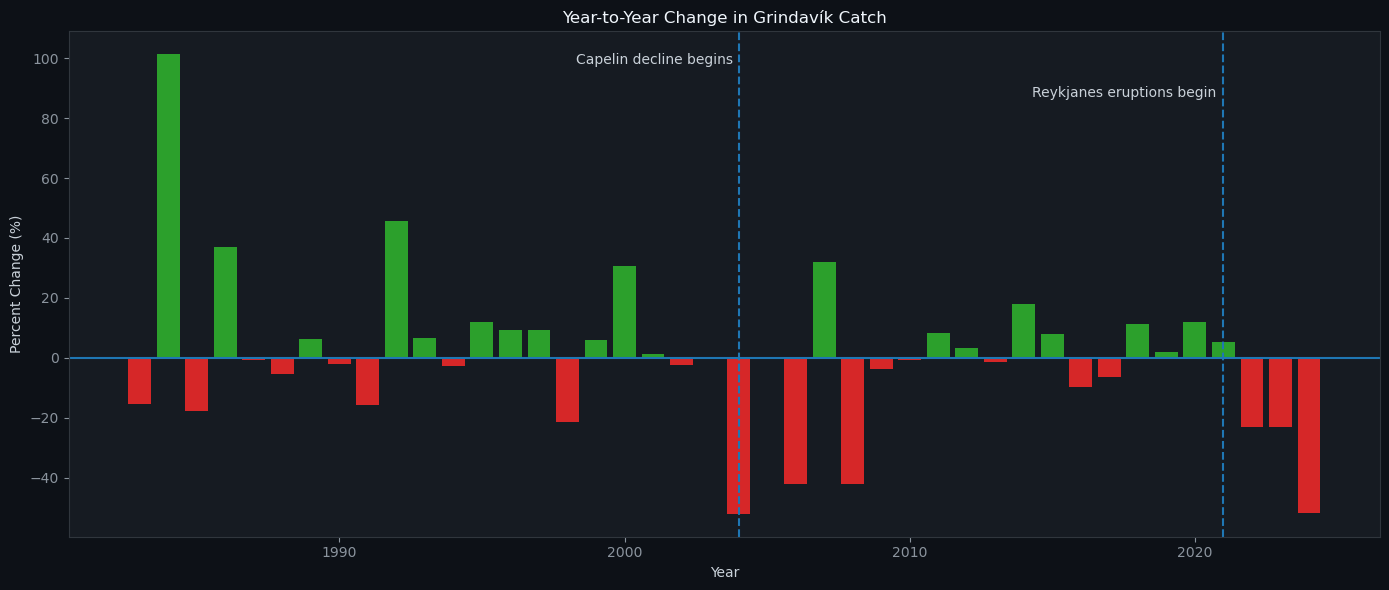

In [6]:
grindavik = (
    df_yearly[df_yearly["Port"] == "Grindavík"]
    .groupby("Year")["Quantity"]
    .sum()
    .sort_index()
)

pct_change = grindavik.pct_change() * 100

plt.figure(figsize=(14, 6))
colors = ['#2ca02c' if x >= 0 else '#d62728' for x in pct_change.values]
plt.bar(
    pct_change.index,
    pct_change.values,
    color=colors
)
plt.axhline(0)
plt.axvline(2004, linestyle="--")
plt.axvline(2021, linestyle="--")
plt.text(2004 - 5.7, plt.ylim()[1]*0.9, "Capelin decline begins")
plt.text(2021 - 6.7, plt.ylim()[1]*0.8, "Reykjanes eruptions begin")
plt.title("Year-to-Year Change in Grindavík Catch")
plt.xlabel("Year")
plt.ylabel("Percent Change (%)")
plt.tight_layout()
plt.show()

In [7]:
import base64, io

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150,
                facecolor=fig.get_facecolor())
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

# ── Theme ──────────────────────────────────────────────────────────────────────
BG    = "#0d1117"
PANEL = "#161b22"
GRID  = "#30363d"
TEXT  = "#c9d1d9"
MUTED = "#8b949e"
BLUE  = "#58a6ff"
ORNG  = "#ffa657"

plt.rcParams.update({
    "figure.facecolor": BG,  "axes.facecolor": PANEL,
    "axes.edgecolor":   GRID, "axes.labelcolor": TEXT,
    "xtick.color": MUTED,    "ytick.color": MUTED,
    "text.color":  TEXT,     "axes.titlecolor": "#f0f6fc",
    "grid.color":  GRID,     "legend.facecolor": PANEL,
    "legend.edgecolor": GRID, "font.family": "DejaVu Sans",
})

SPECIES_COLORS = {
    "Capelin": "#1f77b4", "Cod": "#ff7f0e", "Haddock": "#2ca02c",
    "Herring": "#d62728", "Mackerel": "#9467bd",
}

# ── Plot 1 — catch by species ──────────────────────────────────────────────────
grindavik_df = df_yearly[df_yearly["Port"] == "Grindavík"]
species_port = (
    grindavik_df.groupby(["Year", "Species"])["Quantity"]
    .sum().unstack(fill_value=0)
)
fig1, ax1 = plt.subplots(figsize=(12, 5))
for col in species_port.columns:
    kw = {"color": SPECIES_COLORS[col]} if col in SPECIES_COLORS else {}
    ax1.plot(species_port.index, species_port[col], linewidth=2, label=col, **kw)
ax1.set_title("Grindavík Catch by Species")
ax1.set_xlabel("Year")
ax1.set_ylabel("Quantity (tonnes)")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
img1 = fig_to_b64(fig1)
plt.close(fig1)

# ── Plot 2 — compared to other major ports ────────────────────────────────────
top_ports_list = df_yearly.groupby("Port")["Quantity"].sum().nlargest(8).index
pivot_ports = (
    df_yearly[df_yearly["Port"].isin(top_ports_list)]
    .groupby(["Year", "Port"])["Quantity"].sum()
    .unstack(fill_value=0)
)
fig2, ax2 = plt.subplots(figsize=(12, 5))
for port in pivot_ports.columns:
    if port != "Grindavík":
        ax2.plot(pivot_ports.index, pivot_ports[port],
                 color="gray", alpha=0.4, linewidth=1.5)
ax2.plot(pivot_ports.index, pivot_ports["Grindavík"],
         color=BLUE, linewidth=3, label="Grindavík")
ylim2 = ax2.get_ylim()
ax2.axvline(2004, linestyle="--", color=MUTED, alpha=0.8, linewidth=1.2)
ax2.axvline(2021, linestyle="--", color=ORNG,  alpha=0.8, linewidth=1.2)
ax2.text(2004 - 5.9, ylim2[1] * 0.90, "Capelin decline begins",    fontsize=9, color=MUTED)
ax2.text(2021 - 6.9, ylim2[1] * 0.80, "Reykjanes eruptions begin", fontsize=9, color=ORNG)
ax2.set_title("Grindavík Compared to Other Major Ports")
ax2.set_xlabel("Year")
ax2.set_ylabel("Catch Quantity (tonnes)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
img2 = fig_to_b64(fig2)
plt.close(fig2)

# ── Plot 3 — year-over-year percent change ────────────────────────────────────
grindavik_total = (
    df_yearly[df_yearly["Port"] == "Grindavík"]
    .groupby("Year")["Quantity"].sum().sort_index()
)
pct_change = grindavik_total.pct_change() * 100
fig3, ax3 = plt.subplots(figsize=(12, 5))
bar_colors = ["#2ca02c" if x >= 0 else "#d62728" for x in pct_change.values]
ax3.bar(pct_change.index, pct_change.values, color=bar_colors)
ax3.axhline(0, color=GRID)
ylim3 = ax3.get_ylim()
ax3.axvline(2004, linestyle="--", color=MUTED, alpha=0.8, linewidth=1.2)
ax3.axvline(2021, linestyle="--", color=ORNG,  alpha=0.8, linewidth=1.2)
ax3.text(2004 - 5.7, ylim3[1] * 0.85, "Capelin decline begins",    fontsize=9, color=MUTED)
ax3.text(2021 - 6.7, ylim3[1] * 0.70, "Reykjanes eruptions begin", fontsize=9, color=ORNG)
ax3.set_title("Year-to-Year Change in Grindavík Catch")
ax3.set_xlabel("Year")
ax3.set_ylabel("Percent Change (%)")
ax3.grid(True, alpha=0.3)
plt.tight_layout()
img3 = fig_to_b64(fig3)
plt.close(fig3)

# ── Text content ───────────────────────────────────────────────────────────────
para1 = (
    "For decades, Grindavík was one of Iceland’s most consistent fishing ports "
    "and saw a consistent rise until a great decline in capelin catches began in 2004. "
    "While several major harbors experienced large fluctuations in landings over time, "
    "Grindavík maintained relatively stable catch volumes after the capelin decline. "
    "This stability reflected the town’s strong fishing infrastructure and its "
    "importance within Iceland’s fisheries sector."
)
para2 = (
    "After 2021, however, the data shows a sharp and sustained decline in landings at "
    "Grindavík. Unlike earlier downturns that were primarily linked to changing fish stocks "
    "or quota allocations, this decline coincides with the volcanic activity on the Reykjanes "
    "Peninsula. Beginning in 2021 and intensifying in later years, repeated eruptions and "
    "seismic activity disrupted daily life, infrastructure, and economic activity in the "
    "region. The fisheries data suggests that these natural events may have significantly "
    "affected the operation of Grindavík as a landing harbor, marking a dramatic shift in "
    "the town’s long-standing role in Icelandic fisheries."
)

# ── HTML ───────────────────────────────────────────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Grindavík — Iceland Fisheries</title>
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=DM+Sans:ital,wght@0,400;0,500;0,700;1,400&display=swap">
<style>
  * {{ margin: 0; padding: 0; box-sizing: border-box; }}
  body {{
    font-family: 'DM Sans', sans-serif;
    background: #0d1117;
    color: #c9d1d9;
  }}

  /* ── Navbar ── */
  .navbar {{
    position: fixed;
    top: 0; left: 0; right: 0;
    height: 52px;
    background: rgba(13,17,23,0.94);
    backdrop-filter: blur(12px);
    -webkit-backdrop-filter: blur(12px);
    border-bottom: 1px solid #21262d;
    z-index: 1000;
    display: flex;
    align-items: center;
    padding: 0 20px;
    gap: 14px;
  }}

  .navbar-brand {{
    font-size: 14px;
    font-weight: 700;
    color: #f0f6fc;
    white-space: nowrap;
    flex-shrink: 0;
    line-height: 1.15;
    text-decoration: none;
  }}

  .navbar-brand .brand-sub {{
    display: block;
    font-size: 10px;
    font-weight: 400;
    color: #8b949e;
    letter-spacing: 0.02em;
  }}

  .navbar-sep {{
    width: 1px;
    height: 26px;
    background: #21262d;
    flex-shrink: 0;
  }}

  .stories-label {{
    font-size: 10px;
    font-weight: 600;
    color: #484f58;
    text-transform: uppercase;
    letter-spacing: 0.08em;
    white-space: nowrap;
    flex-shrink: 0;
  }}

  .story-tag {{
    font-size: 12.5px;
    color: #c9d1d9;
    font-weight: 500;
    white-space: nowrap;
    flex-shrink: 0;
  }}

  .navbar-spacer {{ flex: 1; }}

  .back-link {{
    display: flex;
    align-items: center;
    gap: 6px;
    font-size: 12.5px;
    color: #58a6ff;
    text-decoration: none;
    padding: 5px 11px;
    border-radius: 6px;
    border: 1px solid rgba(88,166,255,0.25);
    white-space: nowrap;
    flex-shrink: 0;
    transition: background 0.2s, border-color 0.2s;
  }}

  .back-link:hover {{
    background: rgba(88,166,255,0.1);
    border-color: rgba(88,166,255,0.5);
  }}

  /* ── Story layout ── */
  .story-wrap {{
    max-width: 880px;
    margin: 0 auto;
    padding: 80px 32px 96px;
  }}

  .story-meta {{
    font-size: 11px;
    font-weight: 600;
    color: #484f58;
    text-transform: uppercase;
    letter-spacing: 0.1em;
    margin-bottom: 14px;
  }}

  h1 {{
    font-size: 34px;
    font-weight: 700;
    color: #f0f6fc;
    line-height: 1.25;
    letter-spacing: -0.5px;
    margin-bottom: 28px;
    padding-bottom: 24px;
    border-bottom: 1px solid #21262d;
  }}

  .story-body p {{
    font-size: 16px;
    line-height: 1.85;
    color: #c9d1d9;
    margin-bottom: 36px;
  }}

  .story-figure {{
    margin: 0 0 44px;
  }}

  .story-figure img {{
    width: 100%;
    border-radius: 8px;
    border: 1px solid #21262d;
    display: block;
    background: #161b22;
  }}

  .story-figure figcaption {{
    font-size: 12px;
    color: #484f58;
    margin-top: 8px;
    padding-left: 2px;
    font-style: italic;
    line-height: 1.5;
  }}
</style>
</head>
<body>

<nav class="navbar">
  <a href="iceland_catch_map_slider.html" class="navbar-brand">
    Iceland Fisheries
    <span class="brand-sub">Interactive Map</span>
  </a>
  <div class="navbar-sep"></div>
  <span class="stories-label">Stories</span>
  <span class="story-tag">Grindavík</span>
  <div class="navbar-spacer"></div>
  <a href="iceland_catch_map_slider.html" class="back-link">&#8592; Back to Map</a>
</nav>

<main class="story-wrap">
  <div class="story-meta">Port Analysis &middot; 1982–2024</div>
  <h1>Grindavík: From Stable Fishing Hub to Volcanic Uncertainty</h1>

  <div class="story-body">

    <p>{para1}</p>

    <figure class="story-figure">
      <img src="data:image/png;base64,{img1}" alt="Grindavík Catch by Species">
      <figcaption>Annual catch at Grindavík broken down by species, 1982–2024.</figcaption>
    </figure>

    <figure class="story-figure">
      <img src="data:image/png;base64,{img2}" alt="Grindavík vs Other Major Ports">
      <figcaption>Grindavík (blue) against Iceland’s other top 7 ports (grey).
      Dashed lines mark the capelin decline (2004) and onset of Reykjanes eruptions (2021).</figcaption>
    </figure>

    <p>{para2}</p>

    <figure class="story-figure">
      <img src="data:image/png;base64,{img3}" alt="Year-over-Year Change in Grindavík Catch">
      <figcaption>Year-to-year percent change in total landings at Grindavík.
      Green bars indicate growth; red bars indicate decline.</figcaption>
    </figure>

  </div>
</main>

</body>
</html>"""

with open("grindavik.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✓ Saved grindavik.html")


✓ Saved grindavik.html
